In [1]:
#DATA CLEANING SCRIPT
import pandas as pd
import numpy as np
import re
import sys

# Redirect output to both console and file for Part 1
class DualOutput:
    def __init__(self, filename):
        self.terminal = sys.stdout
        self.log = open(filename, "w", encoding="utf-8")
    def write(self, message):
        self.terminal.write(message)
        self.log.write(message)
    def flush(self):
        self.terminal.flush()
        self.log.flush()

sys.stdout = DualOutput("data_cleaning.txt")

# ==============================
# Step 1: Display first few rows
# ==============================
file_path = r"D:\Gradtwin\House Prediction\Chennai houseing sale.csv"  # Change to your CSV file path
df = pd.read_csv(file_path)

print("First 5 rows of the dataset:")
print(df.head())
print(df.tail())

# =======================================
# Step 2: Dataset Columns
# =======================================
print("\n\n\ndataset columns:")
print(df.columns)

# =======================================
# Step 3: Data Types
# =======================================
print("\n\n\nData Types:")
print(df.dtypes)
# =======================================
# Step 4: Identify Missing Values
# =======================================
print("\n\n\nMissing Values in Each Column:")
print(df.info())
print(df.isnull().sum())

# ===================================================================================
# Step 5: Data Cleaning - Remove rows with only special characters or NaN in any cell
# ===================================================================================
def contains_only_special_chars(value):
    if pd.isna(value):
     
     
        return True
    return bool(re.fullmatch(r'[^a-zA-Z0-9]+', str(value)))

df_cleaned = df[~df.applymap(contains_only_special_chars).any(axis=1)]

print("\n\n\nAfter cleaning (removing rows with only special characters or NaN in any column):")
print(df_cleaned.head())

# Save cleaned data for Part 2
cleaned_file_path = "cleaned_file.csv"
df_cleaned.to_csv(cleaned_file_path, index=False)
print(f"\n\n\nCleaned data saved to {cleaned_file_path}")

# Restore stdout
sys.stdout.log.close()
sys.stdout = sys.stdout.terminal



First 5 rows of the dataset:
   PRT_ID        AREA  INT_SQFT   DATE_SALE  DIST_MAINROAD  N_BEDROOM  \
0  P03210  Karapakkam      1004  04-05-2011            131        1.0   
1  P09411  Anna Nagar      1986  19-12-2006             26        2.0   
2  P01812       Adyar       909  04-02-2012             70        1.0   
3  P05346   Velachery      1855  13-03-2010             14        3.0   
4  P06210  Karapakkam      1226  05-10-2009             84        1.0   

   N_BATHROOM  N_ROOM SALE_COND PARK_FACIL  ... UTILITY_AVAIL  STREET MZZONE  \
0         1.0       3  AbNormal        Yes  ...        AllPub   Paved      A   
1         1.0       5  AbNormal         No  ...        AllPub  Gravel     RH   
2         1.0       3  AbNormal        Yes  ...           ELO  Gravel     RL   
3         2.0       5    Family         No  ...       NoSewr    Paved      I   
4         1.0       3  AbNormal        Yes  ...        AllPub  Gravel      C   

  QS_ROOMS QS_BATHROOM  QS_BEDROOM  QS_OVERALL  REG

C:\Users\Pandi selvam\AppData\Local\Temp\ipykernel_23560\1346062345.py:59: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_cleaned = df[~df.applymap(contains_only_special_chars).any(axis=1)]


In [5]:
#BASIC STATISTICS AND NORMALIZATION SCRIPT
import pandas as pd
import numpy as np
import sys

# Redirect output to both console and file for Part 2
class DualOutput:
    def __init__(self, filename):
        self.terminal = sys.stdout
        self.log = open(filename, "w", encoding="utf-8")
    def write(self, message):
        self.terminal.write(message)
        self.log.write(message)
    def flush(self):
        self.terminal.flush()
        self.log.flush()

sys.stdout = DualOutput("statistics & normalization.txt")

# Load cleaned data from Part 1
cleaned_file_path = "cleaned_file.csv"
df_cleaned = pd.read_csv(cleaned_file_path)

# =======================================
# Step 1: Basic Statistics
# =======================================
print("\nBasic Statistics of Cleaned Data:")
print(df_cleaned.describe())
# ===============================================================
# Step 2: Calculate Basic Statistics for Numerical Columns
# Based on cleaned data & display all column values
# ===============================================================
numerical_cols = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()


print("\n\n\nBasic Statistics (Cleaned Data):")
for col in numerical_cols:
    mean_val = np.mean(df_cleaned[col])
    median_val = np.median(df_cleaned[col])
    mode_val = df_cleaned[col].mode()[0] if not df_cleaned[col].mode().empty else np.nan
    
    print(f"\nColumn: {col}")
    print(f"Mean: {mean_val}")
    print(f"Median: {median_val}")
    print(f"Mode: {mode_val}")

# ===============================================================
# Step 3: Normalize Numerical Features using Min-Max Scaling
# Based on cleaned data & display all column values
# ===============================================================
print("\n\n\nNormalized Numerical Features (Cleaned Data):")
normalized_df = df_cleaned.copy()

for col in numerical_cols:
    min_val = df_cleaned[col].min()
    max_val = df_cleaned[col].max()
    if max_val - min_val != 0:
        normalized_df[col] = (df_cleaned[col] - min_val) / (max_val - min_val)
    else:
        normalized_df[col] = 0  # Avoid division by zero

print(normalized_df[numerical_cols].head())

# ===============================================================
# Step 4: Save the normalized data
# ===============================================================
normalized_df.to_csv('normalized_dataset.csv', index=False)
print("\n\n\nNormalized data saved to 'normalized_dataset.csv'")

# Restore stdout
sys.stdout.log.close()
sys.stdout = sys.stdout.terminal




Basic Statistics of Cleaned Data:
          INT_SQFT  DIST_MAINROAD    N_BEDROOM   N_BATHROOM       N_ROOM  \
count  7056.000000    7056.000000  7056.000000  7056.000000  7056.000000   
mean   1381.316752      99.569161     1.636621     1.213152     3.686650   
std     457.860850      57.403870     0.803633     0.409563     1.020011   
min     500.000000       0.000000     1.000000     1.000000     2.000000   
25%     991.000000      50.000000     1.000000     1.000000     3.000000   
50%    1369.500000      99.000000     1.000000     1.000000     4.000000   
75%    1744.000000     148.000000     2.000000     1.000000     4.000000   
max    2500.000000     200.000000     4.000000     2.000000     6.000000   

          QS_ROOMS  QS_BATHROOM   QS_BEDROOM   QS_OVERALL        REG_FEE  \
count  7056.000000  7056.000000  7056.000000  7056.000000    7056.000000   
mean      3.517177     3.505896     3.485332     3.503389  376791.852608   
std       0.892141     0.897644     0.886814     0.5

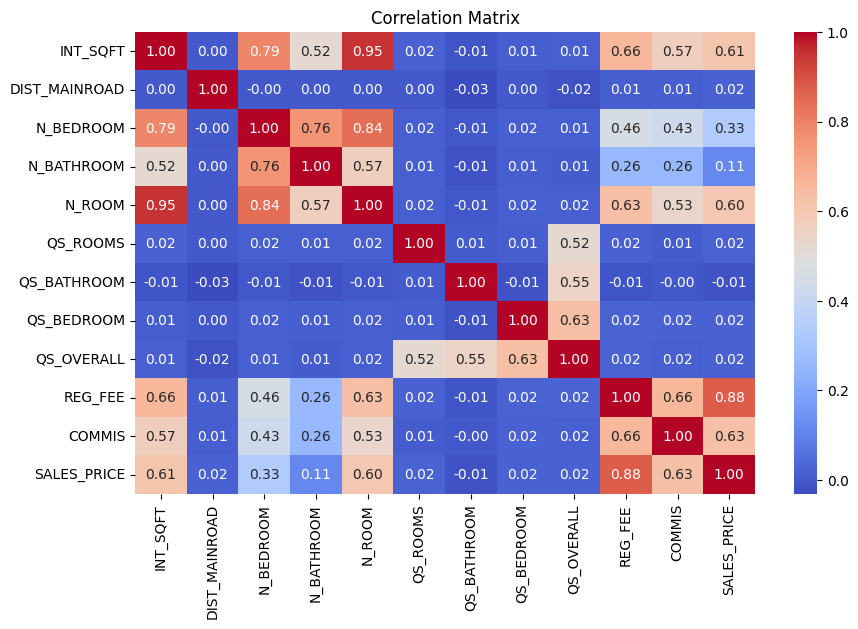

In [6]:
# EXPLORATORY DATA ANALYSIS
import seaborn as sns
import matplotlib.pyplot as plt

df_cleaned = pd.read_csv(r"D:\Gradtwin\House Prediction\normalized_dataset.csv")

# =========================
# Step : Correlation Matrix
# =========================
corr_matrix = df_cleaned.corr(numeric_only=True)
# print("\nCorrelation Matrix (Numeric Columns):")
# print(corr_matrix)

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


Dataset Loaded
   PRT_ID        AREA  INT_SQFT   DATE_SALE  DIST_MAINROAD  N_BEDROOM  \
0  P03210  Karapakkam      1004  04-05-2011            131        1.0   
1  P09411  Anna Nagar      1986  19-12-2006             26        2.0   
2  P01812       Adyar       909  04-02-2012             70        1.0   
3  P05346   Velachery      1855  13-03-2010             14        3.0   
4  P06210  Karapakkam      1226  05-10-2009             84        1.0   

   N_BATHROOM  N_ROOM SALE_COND PARK_FACIL  ... UTILITY_AVAIL  STREET MZZONE  \
0         1.0       3  AbNormal        Yes  ...        AllPub   Paved      A   
1         1.0       5  AbNormal         No  ...        AllPub  Gravel     RH   
2         1.0       3  AbNormal        Yes  ...           ELO  Gravel     RL   
3         2.0       5    Family         No  ...       NoSewr    Paved      I   
4         1.0       3  AbNormal        Yes  ...        AllPub  Gravel      C   

  QS_ROOMS QS_BATHROOM  QS_BEDROOM  QS_OVERALL  REG_FEE  COMMIS  

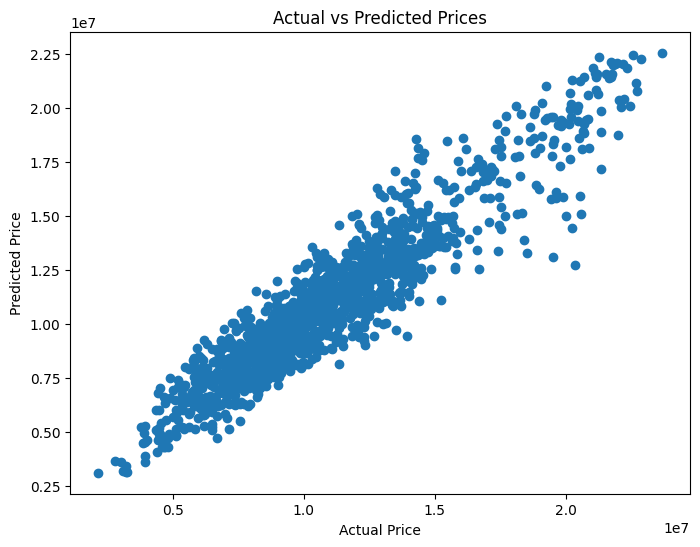

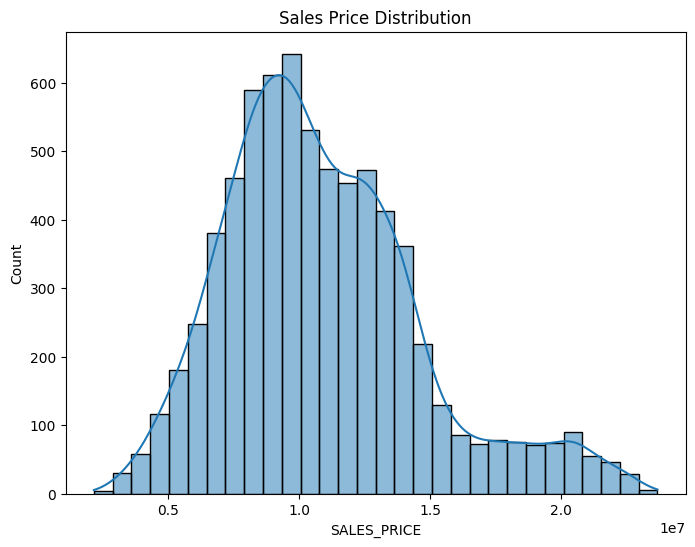

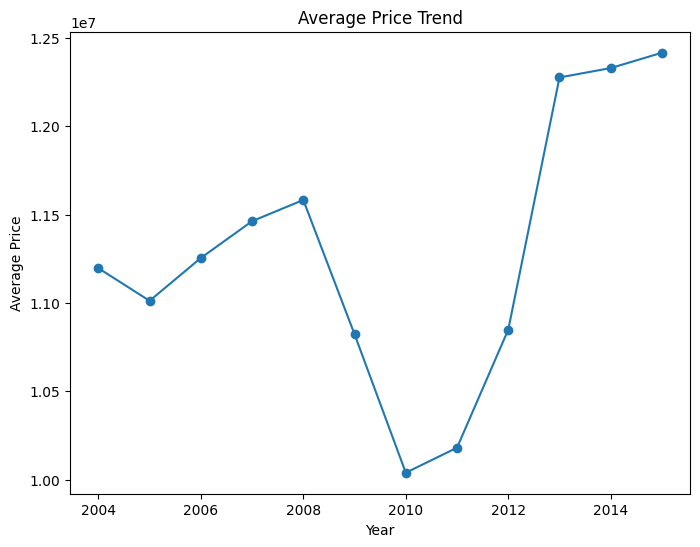

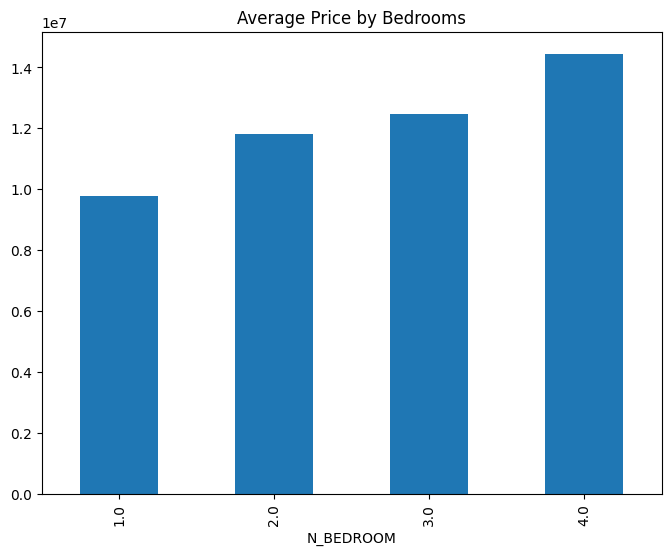

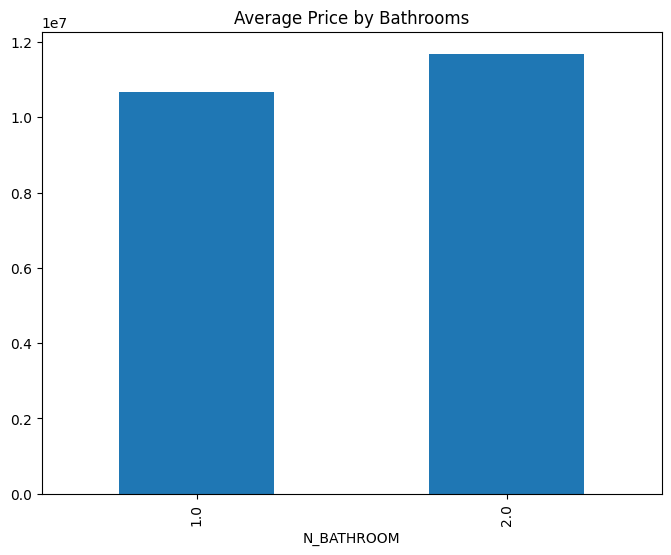

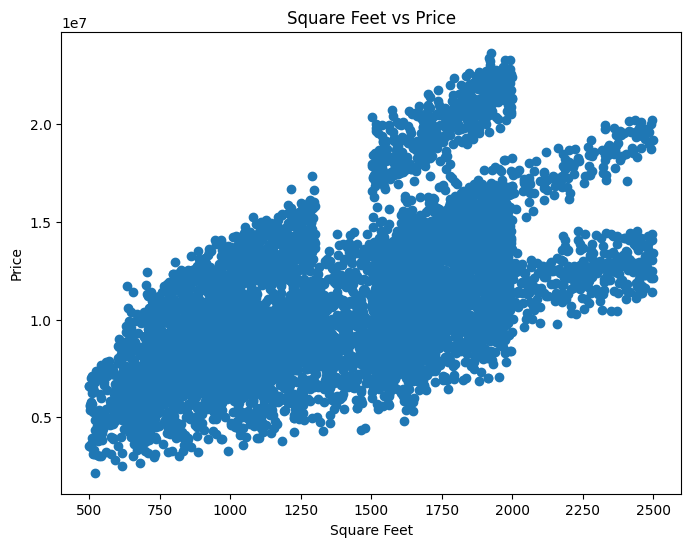

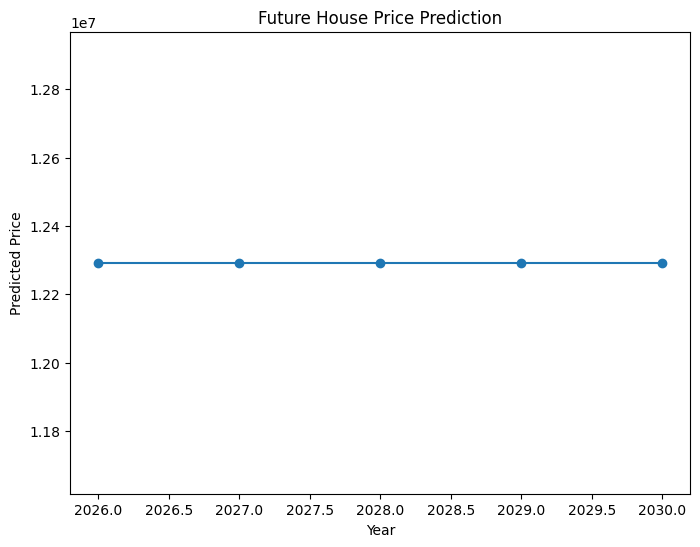

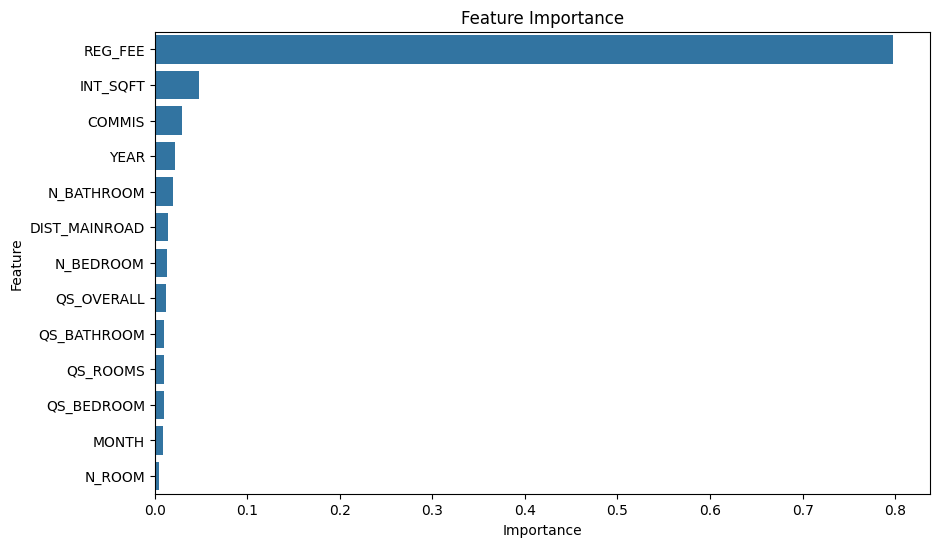

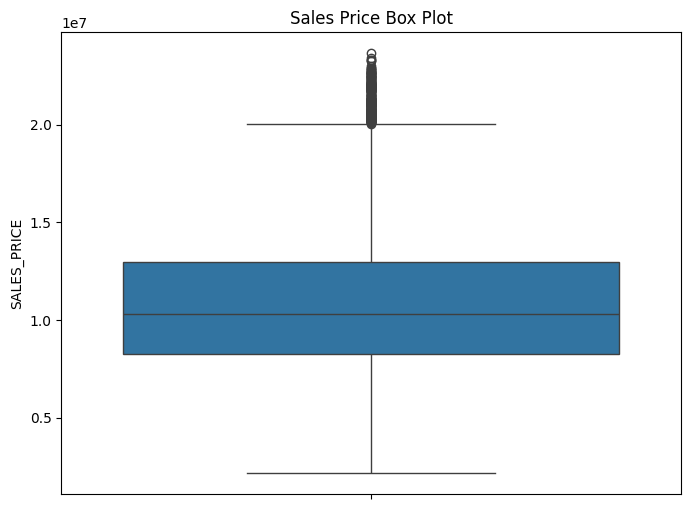

Future prediction file saved


In [ ]:
# =====================================================
# 1. Import Libraries
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


# =====================================================
# 2. Load Dataset
# =====================================================

df = pd.read_csv("cleaned_file.csv")

print("Dataset Loaded")
print(df.head())


# =====================================================
# 3. Convert Date Column
# =====================================================

df['DATE_SALE'] = pd.to_datetime(df['DATE_SALE'], dayfirst=True)

df['YEAR'] = df['DATE_SALE'].dt.year
df['MONTH'] = df['DATE_SALE'].dt.month


# =====================================================
# 4. Select Features
# =====================================================

features = [
    'INT_SQFT',
    'DIST_MAINROAD',
    'N_BEDROOM',
    'N_BATHROOM',
    'N_ROOM',
    'QS_ROOMS',
    'QS_BATHROOM',
    'QS_BEDROOM',
    'QS_OVERALL',
    'REG_FEE',
    'COMMIS',
    'YEAR',
    'MONTH'
]

X = df[features]
y = df['SALES_PRICE']


# =====================================================
# 5. Train Test Split
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


# =====================================================
# 6. Train Model
# =====================================================

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Training Completed")


# =====================================================
# 7. Prediction
# =====================================================

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


# =====================================================
# 8. Future Prediction
# =====================================================

future_years = np.arange(2026, 2031)

future_prices = []

for year in future_years:

    sample = X.mean().to_frame().T
    sample['YEAR'] = year
    sample['MONTH'] = 1

    pred = model.predict(sample)

    future_prices.append(pred[0])


# =====================================================
# 9. Plot 1 : Actual vs Predicted
# =====================================================

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()


# =====================================================
# 10. Plot 2 : Sales Price Distribution
# =====================================================

plt.figure(figsize=(8,6))
sns.histplot(df['SALES_PRICE'], bins=30, kde=True)

plt.title("Sales Price Distribution")

plt.show()


# =====================================================
# 11. Plot 3 : Correlation Heatmap
# =====================================================

# plt.figure(figsize=(10,8))

# sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

# plt.title("Correlation Matrix")

# plt.show()


# =====================================================
# 12. Plot 4 : Price Trend by Year
# =====================================================

trend = df.groupby('YEAR')['SALES_PRICE'].mean()

plt.figure(figsize=(8,6))

trend.plot(marker='o')

plt.title("Average Price Trend")

plt.xlabel("Year")
plt.ylabel("Average Price")

plt.show()


# =====================================================
# 13. Plot 5 : Bedrooms vs Price
# =====================================================

bed_price = df.groupby('N_BEDROOM')['SALES_PRICE'].mean()

plt.figure(figsize=(8,6))

bed_price.plot(kind='bar')

plt.title("Average Price by Bedrooms")

plt.show()


# =====================================================
# 14. Plot 6 : Bathrooms vs Price
# =====================================================

bath_price = df.groupby('N_BATHROOM')['SALES_PRICE'].mean()

plt.figure(figsize=(8,6))

bath_price.plot(kind='bar')

plt.title("Average Price by Bathrooms")

plt.show()


# =====================================================
# 15. Plot 7 : Price vs Square Feet
# =====================================================

plt.figure(figsize=(8,6))

plt.scatter(df['INT_SQFT'], df['SALES_PRICE'])

plt.xlabel("Square Feet")
plt.ylabel("Price")

plt.title("Square Feet vs Price")

plt.show()


# =====================================================
# 16. Plot 8 : Future Prediction Chart
# =====================================================

plt.figure(figsize=(8,6))

plt.plot(future_years, future_prices, marker='o')

plt.title("Future House Price Prediction")

plt.xlabel("Year")
plt.ylabel("Predicted Price")

plt.show()


# =====================================================
# 17. Plot 9 : Feature Importance
# =====================================================

importance = model.feature_importances_

imp_df = pd.DataFrame({
    'Feature':features,
    'Importance':importance
})

imp_df = imp_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))

sns.barplot(x='Importance', y='Feature', data=imp_df)

plt.title("Feature Importance")

plt.show()


# =====================================================
# 18. Plot 10 : Boxplot of Sales Price
# =====================================================

plt.figure(figsize=(8,6))

sns.boxplot(df['SALES_PRICE'])

plt.title("Sales Price Box Plot")

plt.show()


# =====================================================
# 19. Save Future Predictions
# =====================================================

future_df = pd.DataFrame({
    "Year":future_years,
    "Predicted Price":future_prices
})

future_df.to_csv("future_house_price_prediction.csv", index=False)

print("Future prediction file saved")

In [4]:
import pandas as pd

df = pd.read_csv(r"D:\Gradtwin\House Prediction\cleaned_file.csv")

# selected = df[["Column1","Column2"]]
print("Available Columns:", list(df.columns))

cols = input("Enter columns separated by comma: ").split(",")

selected = df[cols]

print(selected)

selected.to_csv(r"D:\Gradtwin\House Prediction\selected_columns.csv", index=False)

print("File saved successfully")

Available Columns: ['PRT_ID', 'AREA', 'INT_SQFT', 'DATE_SALE', 'DIST_MAINROAD', 'N_BEDROOM', 'N_BATHROOM', 'N_ROOM', 'SALE_COND', 'PARK_FACIL', 'DATE_BUILD', 'BUILDTYPE', 'UTILITY_AVAIL', 'STREET', 'MZZONE', 'QS_ROOMS', 'QS_BATHROOM', 'QS_BEDROOM', 'QS_OVERALL', 'REG_FEE', 'COMMIS', 'SALES_PRICE']


KeyError: "None of [Index([''PRD_ID'', ' 'AREA'', ' 'INT_SQFT'', ' 'N_ROOM'', ' 'PARK_FACIL''], dtype='object')] are in the [columns]"